# Fitting Examples

This notebook shows how to use the `fit` library to perform easily fit operations using [RooFit](https://root.cern.ch/doc/master/group__Roofitmain.html).
The fitting operations are built around the [`RooWorkspace`](https://root.cern.ch/doc/master/classRooWorkspace.html) class from RooFit. Let's see how to run simple and complex fits using the helper functions.

## My First Fit

Let's run a simple fit of a Gaussian distribution. To create the workspace and the pdfs, we will use the `FitModels` class, which includes a number of predefined models and relevant variables.

In [1]:
from analysis_helpers.fit import FitModels, add_to_workspace
fm = FitModels()

We first create the RooFit Workspace

In [2]:
ws = fm.simple_workspace('X',-10,10,'Observable','a.u.')
ws.Print('V')

[#1] INFO:ObjectHandling -- RooWorkspace::import(ws) importing RooRealVar::X

RooWorkspace(ws) ws contents

variables
---------
(X)



Let's add the gaussian

In [3]:
gau = fm.gaussian(ws, 'gau', 'X')

[#1] INFO:ObjectHandling -- RooWorkspace::import(ws) importing RooRealVar::gau_m
[#1] INFO:ObjectHandling -- RooWorkspace::import(ws) importing RooRealVar::gau_s
[#0] WARNING:InputArguments -- The parameter 'gau_s' with range [0, 20] of the RooGaussian 'gau_gau' exceeds the safe range of (0, inf). Advise to limit its range.
[#1] INFO:ObjectHandling -- RooWorkspace::import(ws) importing RooGaussian::gau_gau
[#1] INFO:ObjectHandling -- RooWorkspace::import(ws) using existing copy of RooRealVar::X for import of RooGaussian::gau_gau
[#1] INFO:ObjectHandling -- RooWorkspace::import(ws) using existing copy of RooRealVar::gau_m for import of RooGaussian::gau_gau
[#1] INFO:ObjectHandling -- RooWorkspace::import(ws) using existing copy of RooRealVar::gau_s for import of RooGaussian::gau_gau


and generate some data points

In [4]:
data = gau.generate(ws.argSet(['X']),10000)

To fit the data with the model, we can use the functions defined in the class `FitUtils`

In [5]:
from analysis_helpers.fit import FitUtils
fu = FitUtils()

In [6]:
res = fu.fit_to_data(gau, data)

[#1] INFO:Fitting -- RooAbsPdf::fitTo(gau_gau_over_gau_gau_Int[X]) fixing normalization set for coefficient determination to observables in data
[#1] INFO:Fitting -- using generic CPU library compiled with no vectorizations
[#1] INFO:Fitting -- Creation of NLL object took 10.3737 ms
[#1] INFO:Fitting -- RooAddition::defaultErrorLevel(nll_gau_gau_over_gau_gau_Int[X]_gau_gauData) Summation contains a RooNLLVar, using its error level
[#1] INFO:Minimization -- [fitFCN] No discrete parameters, performing continuous minimization only
Minuit2Minimizer: Minimize with max-calls 1000 convergence for edm < 1 strategy 1
Minuit2Minimizer : Valid minimum - status = 0
FVAL  = 21094.3162864796795
Edm   = 9.62099763727808778e-07
Nfcn  = 26
gau_m	  = 0.0132935	 +/-  0.0199475	(limited)
gau_s	  = 1.99473	 +/-  0.0141063	(limited)
Fit Result
Fit status = 0
Minuit status = 3
Number of Loops = 2
Real Time  = 0.05815887451171875
CPU Time  = 0.06000000000000005


Info in <Minuit2>: MnSeedGenerator Computing seed using NumericalGradient calculator
Info in <Minuit2>: MnSeedGenerator Evaluated function and gradient in 731.291 μs
Info in <Minuit2>: MnSeedGenerator Initial state: FCN =       21094.60709 Edm =      0.2898383621 NCalls =     11
Info in <Minuit2>: MnSeedGenerator Initial state  
  Minimum value : 21094.60709
  Edm           : 0.2898383621
  Internal parameters:	[                0     -0.927295218]	
  Internal gradient  :	[     -332.3324515      157.0014147]	
  Internal covariance matrix:
[[  8.0001298e-06              0]
 [              0  1.1188092e-05]]]
Info in <Minuit2>: VariableMetricBuilder Start iterating until Edm is < 0.001 with call limit = 1000
Info in <Minuit2>: VariableMetricBuilder    0 - FCN =       21094.60709 Edm =      0.2898383621 NCalls =     11
Info in <Minuit2>: VariableMetricBuilder    1 - FCN =       21094.31629 Edm =   9.132317841e-07 NCalls =     16
Info in <Minuit2>: MnHesse Done after 643.125 μs
Info in <Min

[#1] INFO:Fitting -- RooAbsPdf::fitTo(gau_gau_over_gau_gau_Int[X]) fixing normalization set for coefficient determination to observables in data
[#1] INFO:Fitting -- Creation of NLL object took 93.834 μs
[#1] INFO:Fitting -- RooAddition::defaultErrorLevel(nll_gau_gau_over_gau_gau_Int[X]_gau_gauData) Summation contains a RooNLLVar, using its error level
[#1] INFO:Minimization -- [fitFCN] No discrete parameters, performing continuous minimization only
Minuit2Minimizer: Minimize with max-calls 1000 convergence for edm < 1 strategy 1
Minuit2Minimizer : Valid minimum - status = 0
FVAL  = 21094.316285516099
Edm   = 9.42678224089769987e-10
Nfcn  = 25
gau_m	  = 0.0132935	 +/-  0.0199473	(limited)
gau_s	  = 1.99471	 +/-  0.014106	(limited)

  RooFitResult: minimized FCN value: 21094.3, estimated distance to minimum: 9.45535e-10
                covariance matrix quality: Full, accurate covariance matrix
                Status : MINIMIZE=0 HESSE=0 

    Floating Parameter  InitialValue    FinalVa

Info in <Minuit2>: MnSeedGenerator Computing seed using NumericalGradient calculator
Info in <Minuit2>: MnSeedGenerator Evaluated function and gradient in 329.375 μs
Info in <Minuit2>: MnSeedGenerator Initial state: FCN =       21094.31629 Edm =   9.050480865e-07 NCalls =      5
Info in <Minuit2>: MnSeedGenerator Initial state  
  Minimum value : 21094.31629
  Edm           : 9.050480865e-07
  Internal parameters:	[   0.001329351381    -0.9281734911]	
  Internal gradient  :	[  0.0004275515957      0.571581475]	
  Internal covariance matrix:
[[  7.9580483e-06              0]
 [              0  1.1080904e-05]]]
Info in <Minuit2>: VariableMetricBuilder Start iterating until Edm is < 0.001 with call limit = 1000
Info in <Minuit2>: VariableMetricBuilder    0 - FCN =       21094.31629 Edm =   9.050480865e-07 NCalls =      5
Info in <Minuit2>: VariableMetricBuilder    1 - FCN =       21094.31629 Edm =   2.853980898e-16 NCalls =     11
Info in <Minuit2>: MnHesse Done after 912.875 μs
Info in <

Now plot the data and the fit results superimposed.

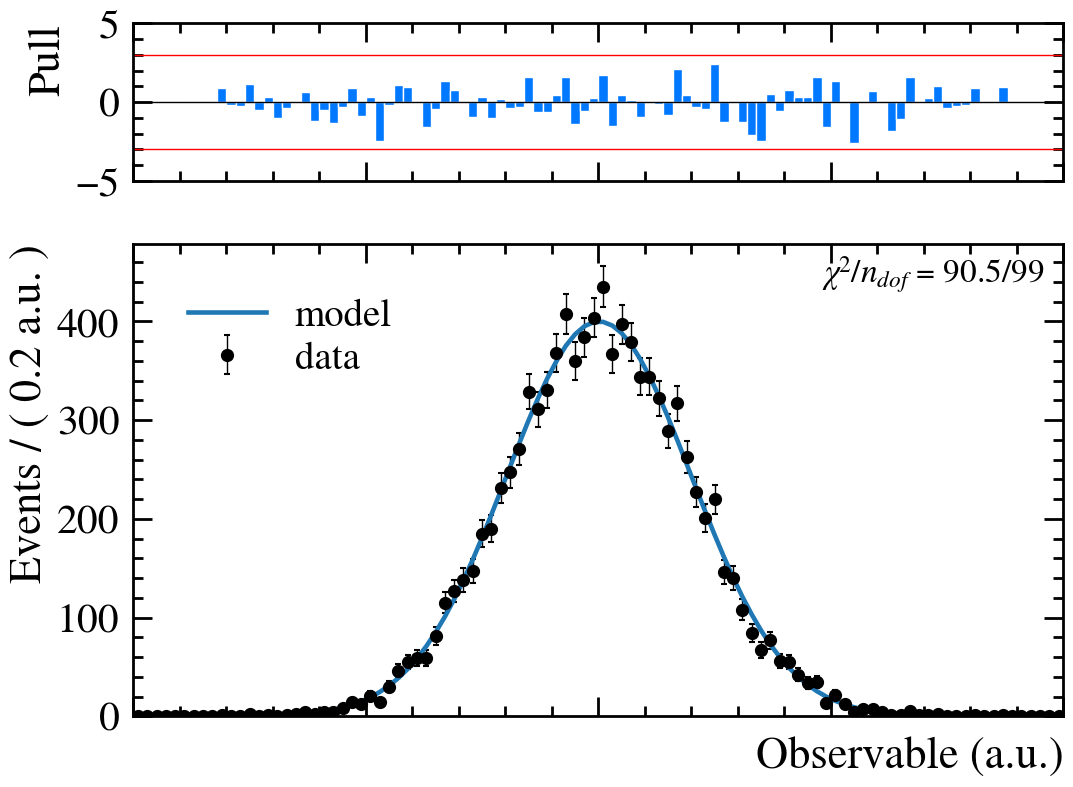

In [7]:
fr = ws.var('X').frame()
data.plotOn(fr)
gau.plotOn(fr)
fig, ax = fu.plot_fit_and_residuals_mpl(fr, labels=['data','model'])